In [17]:
# Imports and installations
#!pip install transformers
#!pip install tqdm boto3 requests regex sentencepiece sacremoses

import copy
import math
import torch
import pandas as pd
import torch.optim as optim
import torch.nn as nn
from sklearn.model_selection import train_test_split
from collections import Counter
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Load dataset
data = pd.read_csv("amazon_cells_labelled.txt", delimiter='\t') # small dataset
#data = pd.read_csv("amazon_cells_labelled_LARGE_25K.txt", delimiter='\t') # big dataset
data.columns = ['Sentence', 'Class']

In [19]:
# Classes and functions
# Preprocessing the dataset
def pre_data(data, max_len=50, test_size=0.2):

    # simple tokenizer (string to tokens)
    def tokenize(text):
        return text.lower().split()

    # indexes words
    vocab = Counter(word for s in data['Sentence'] for word in tokenize(s))
    vocab = {w: i+1 for i, w in enumerate(vocab)}

    # encodes sentences into indices + padding
    X = []
    for sentence in data['Sentence']:
        tokens = [vocab.get(w, 0) for w in tokenize(sentence)]
        tokens = tokens[:max_len] + [0]*(max_len - len(tokens))
        X.append(tokens)

    # converts them to tensors
    X = torch.tensor(X, dtype=torch.long)
    y = torch.tensor(data['Class'].values, dtype=torch.long)

    # splits into training / test sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size)
    return X_train, X_test, y_train, y_test, vocab


# Transformer
class TransformerModel(nn.Module):
    def __init__(self, vocab_size, d_model=64, nhead=4, num_layers=2, max_len=50):
        super().__init__()

        # index to vector (tensor)
        self.embedding = nn.Embedding(vocab_size+1, d_model)

        # positional encoding (makes the order of the words important)
        pe = torch.zeros(max_len, d_model)
        for pos in range(max_len):
            for i in range(0, d_model, 2):
                pe[pos, i] = math.sin(pos / (10000 ** (i / d_model)))
                if i+1 < d_model:
                    pe[pos, i+1] = math.cos(pos / (10000 ** (i / d_model)))
        self.pe = pe.unsqueeze(0)
        
        # transformer encoder
        layer = nn.TransformerEncoderLayer(d_model, nhead, batch_first=True)
        self.transformer = nn.TransformerEncoder(layer, num_layers)

        # final classification layer
        self.fc = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.embedding(x) # tokens to embeddings
        x = x + self.pe[:, :x.size(1)] # adds the positional encoding
        x = self.transformer(x) # applies the transformer encoder
        return self.fc(x.mean(dim=1)) # pools and classifies


# Training
def train_model(model, trainloader, X_test, y_test, optimizer, criterion, epochs=10):
    train_losses = []
    val_losses = []

    # early stopping and best model tracking
    early_stop = 0
    best_acc = 0
    best_model = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        model.train()
        running_loss = 0
        correct = 0
        total = 0

        # training loop
        for inputs, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # computes training acc
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_loss = running_loss / len(trainloader)
        train_losses.append(train_loss)

        # model eval
        model.eval()
        with torch.no_grad():
            outputs = model(X_test)
            val_loss = criterion(outputs, y_test).item()
            val_losses.append(val_loss)

            _, preds = torch.max(outputs, 1)
            val_acc = (preds == y_test).float().mean().item()

        # saves best model
        if val_acc > best_acc:
            best_acc = val_acc
            best_model = copy.deepcopy(model.state_dict())
        else:
            early_stop += 1

        # early stopping in case its been bad for 3 epochs
        if early_stop >= 3:
            break

        print(f"{epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}, val_acc={val_acc:.4f}")

    model.load_state_dict(best_model)

    return train_losses, val_losses

# Evaluation and plotting
def evaluate(model, X_test, y_test, train_losses, val_losses):
    model.eval()
    with torch.no_grad():
        outputs = model(X_test)
        preds = torch.argmax(outputs, dim=1)

    accuracy = (preds == y_test).float().mean().item()
    print(f"Accuracy: {accuracy:.4f}")

    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.show()

    return accuracy
    

1: train=0.7145, val=0.6822, val_acc=0.5500
2: train=0.6931, val=0.6977, val_acc=0.4650
3: train=0.6676, val=0.6457, val_acc=0.6050
4: train=0.6060, val=0.6821, val_acc=0.5600
5: train=0.5337, val=0.5636, val_acc=0.6600
6: train=0.4865, val=0.5469, val_acc=0.6750
7: train=0.3939, val=0.5751, val_acc=0.6850
8: train=0.3641, val=0.5382, val_acc=0.7100
9: train=0.2991, val=0.6260, val_acc=0.7150
Accuracy: 0.7150


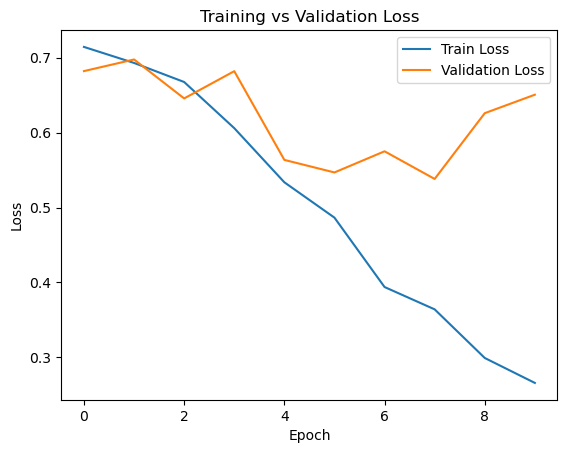

Accuracy: 0.7149999737739563


In [21]:
# 1.2 Main
max_len = 50 # Sentence length is 50 tokens max
lr = 0.0001
epochs = 15

# Insert data into preprocessing
X_train, X_test, y_train, y_test, vocab = pre_data(data)

# Create dataloader to be able to batch train
trainloader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True
)

# Initialize transformer model
model = TransformerModel(
    vocab_size=len(vocab),
    d_model=128,
    nhead=4,
    num_layers=2
)

optimizer = torch.optim.Adam(model.parameters(), lr)
criterion = nn.CrossEntropyLoss()

# Trains the model
train_losses, val_losses = train_model(
    model,
    trainloader,
    X_test,
    y_test,
    optimizer,
    criterion,
)

# Evaluates the model
accuracy = evaluate(model, X_test, y_test, train_losses, val_losses)
print("Accuracy:", accuracy)